## ② Outlier Cycle Candidate 부족 원인 검증

기존 adaptive detector를 segment별로 재현하고, 길이 제외·AI2 변동성·prominence·peak 수를 분리해 본다. 그 뒤 Normal segment에서 산출한 prominence 중앙값을 고정 비교값으로 정해 Outlier에 그대로 적용한다. 고정 threshold 결과는 peak 수 자체가 아니라 파형 위치와 cycle duration까지 검토한다.

Normal: segment-level detector diagnostics (all segments)


,dataset,segment_id,n_samples,AI2_std,current_prominence,peak_count,candidate_cycle_count,eligible_by_length
0,Normal,0,1,0.000000,2.220446e-16,0,0,False
1,Normal,1,40,146.457596,7.322880e+01,2,1,True
2,Normal,2,37,138.820529,6.941026e+01,2,1,True
3,Normal,3,24,79.872493,3.993625e+01,0,0,False
4,Normal,4,10,160.583249,8.029162e+01,0,0,False
...,...,...,...,...,...,...,...,...
598,Normal,598,35,180.948540,9.047427e+01,2,1,True
599,Normal,599,22,99.151659,4.957583e+01,0,0,False
600,Normal,600,8,82.881629,4.144081e+01,0,0,False
601,Normal,601,50,148.550283,7.427514e+01,3,2,True


Normal: eligible segment counts; segments shorter than 30 are skipped by the existing detector


,count,mean,std,min,25%,50%,75%,max
AI2_std,360.0,116.288351,36.125180,76.161906,84.922561,99.234189,148.728058,184.84142
current_prominence,360.0,58.144175,18.062590,38.080953,42.461280,49.617095,74.364029,92.42071
peak_count,360.0,2.319444,0.583582,1.000000,2.000000,2.000000,3.000000,3.00000


Outlier: segment-level detector diagnostics (all segments)


...

,count,mean,std,min,25%,50%,75%,max
AI2_std,10.0,86.652389,32.354462,29.831217,64.055894,93.461301,113.121077,124.419894
current_prominence,10.0,43.326194,16.177231,14.915609,32.027947,46.730651,56.560539,62.209947
peak_count,10.0,1.800000,0.788811,1.000000,1.000000,2.000000,2.000000,3.000000


Outlier eligible segment counts by peak group:


,segment_count
peak_group,
peak 0,0
peak 1,4
peak 2+,6


Outlier eligible segment details:


,segment_id,n_samples,AI2_std,current_prominence,peak_count
2,2,50,73.181365,36.590682,3
3,3,47,93.389581,46.694791,1
4,4,31,29.831217,14.915609,1
7,7,50,111.125299,55.562649,2
8,8,40,124.419894,62.209947,1
12,12,50,47.946004,23.973002,3
13,13,42,61.014071,30.507035,2
16,16,50,118.297100,59.148550,1
17,17,50,93.533021,46.766511,2
18,18,36,113.786337,56.893168,2


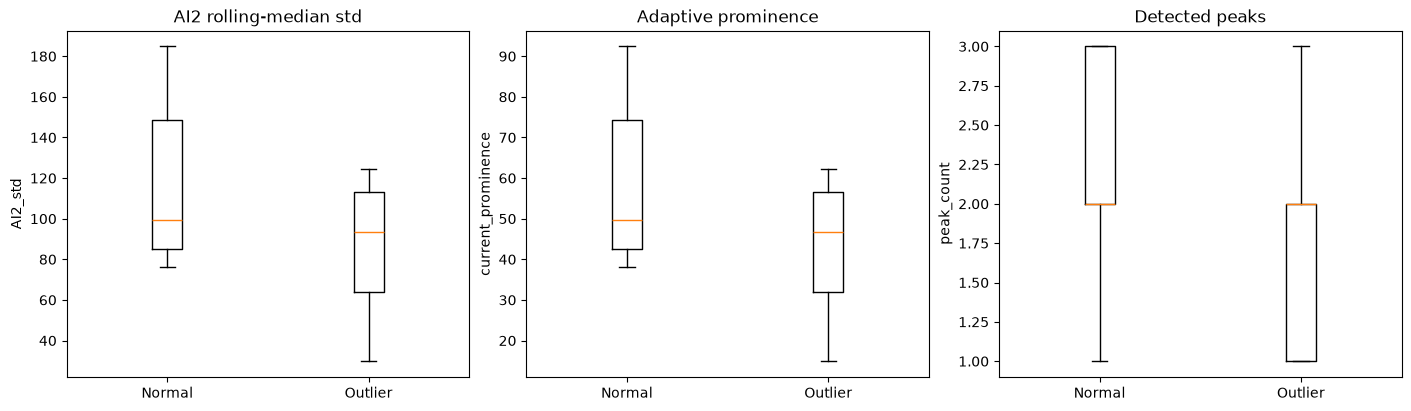

In [ ]:
def segment_peak_diagnostics(df, dataset_name):
    rows = []
    for segment_id, group in df.groupby("segment_id", sort=False):
        values = group[CYCLE_ANCHOR].to_numpy(dtype=float)
        smooth = pd.Series(values).rolling(3, center=True, min_periods=1).median()
        ai2_std = float(smooth.std()) if len(smooth) > 1 else 0.0
        prominence = max(ai2_std * 0.5, np.finfo(float).eps)
        eligible = len(group) >= MIN_SEGMENT_ROWS and np.isfinite(values).all()
        peaks = find_peaks(
            smooth.to_numpy(), distance=CYCLE_MIN_PEAK_DISTANCE_SAMPLES,
            prominence=prominence,
        )[0] if eligible else np.array([], dtype=int)
        rows.append({
            "dataset": dataset_name,
            "segment_id": int(segment_id),
            "n_samples": len(group),
            "AI2_std": ai2_std,
            "current_prominence": prominence,
            "peak_count": len(peaks),
            "candidate_cycle_count": max(len(peaks) - 1, 0),
            "eligible_by_length": eligible,
        })
    return pd.DataFrame(rows)

normal_segment_diagnostics = segment_peak_diagnostics(normal, "Normal")
outlier_segment_diagnostics = segment_peak_diagnostics(outlier, "Outlier")
segment_diagnostics = pd.concat([normal_segment_diagnostics, outlier_segment_diagnostics], ignore_index=True)

for name, diagnostics in [("Normal", normal_segment_diagnostics), ("Outlier", outlier_segment_diagnostics)]:
    print(f"{name}: segment-level detector diagnostics (all segments)")
    display(diagnostics)
    eligible = diagnostics.loc[diagnostics["eligible_by_length"]]
    print(f"{name}: eligible segment counts; segments shorter than {MIN_SEGMENT_ROWS} are skipped by the existing detector")
    display(eligible[["AI2_std", "current_prominence", "peak_count"]].describe().T)

outlier_eligible = outlier_segment_diagnostics.loc[outlier_segment_diagnostics["eligible_by_length"]].copy()
outlier_eligible["peak_group"] = pd.cut(
    outlier_eligible["peak_count"], bins=[-1, 0, 1, np.inf], labels=["peak 0", "peak 1", "peak 2+"],
)
print("Outlier eligible segment counts by peak group:")
display(outlier_eligible["peak_group"].value_counts().reindex(["peak 0", "peak 1", "peak 2+"], fill_value=0).rename("segment_count").to_frame())
print("Outlier eligible segment details:")
display(outlier_eligible[["segment_id", "n_samples", "AI2_std", "current_prominence", "peak_count"]])

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for ax, metric, title in zip(axes, ["AI2_std", "current_prominence", "peak_count"], ["AI2 rolling-median std", "Adaptive prominence", "Detected peaks"]):
    plot_data = [
        normal_segment_diagnostics.loc[normal_segment_diagnostics["eligible_by_length"], metric],
        outlier_segment_diagnostics.loc[outlier_segment_diagnostics["eligible_by_length"], metric],
    ]
    ax.boxplot(plot_data, tick_labels=["Normal", "Outlier"], showfliers=True)
    ax.set_title(title)
    ax.set_ylabel(metric)
plt.show()

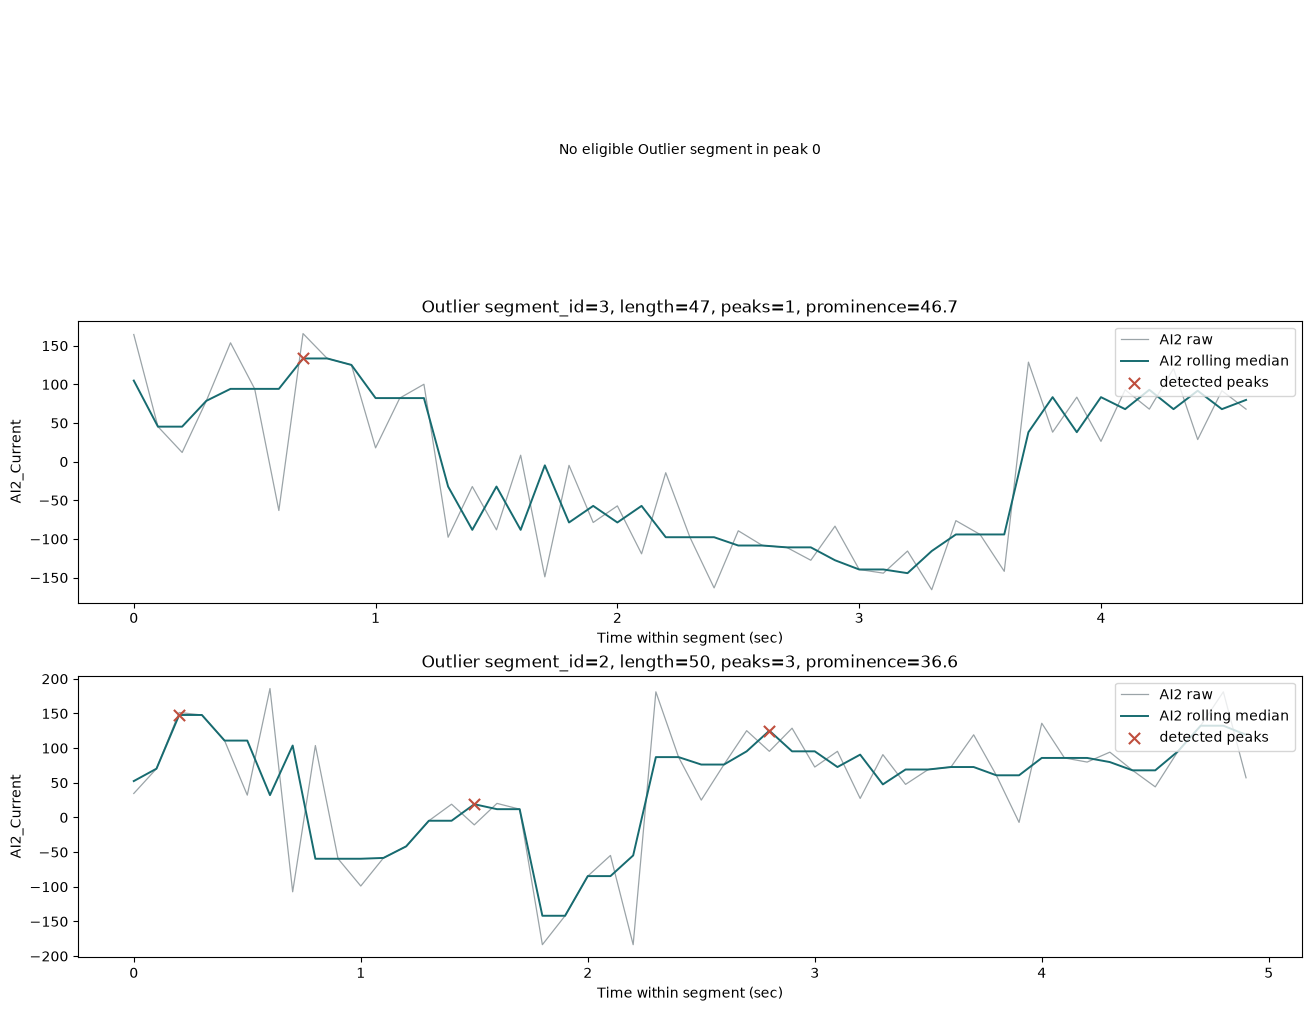

In [ ]:
peak_categories = [("peak 0", 0), ("peak 1", 1), ("peak 2+", 2)]
fig, axes = plt.subplots(len(peak_categories), 1, figsize=(13, 10), squeeze=False, constrained_layout=True)
for row_plot, (category, minimum_peaks) in enumerate(peak_categories):
    ax = axes[row_plot, 0]
    candidates = outlier_eligible.loc[outlier_eligible["peak_group"] == category]
    if candidates.empty:
        ax.text(0.5, 0.5, f"No eligible Outlier segment in {category}", ha="center", va="center")
        ax.set_axis_off()
        continue
    target_std = candidates["AI2_std"].median()
    chosen = candidates.iloc[(candidates["AI2_std"] - target_std).abs().argsort()[:1]]
    segment_id = int(chosen.iloc[0]["segment_id"])
    group = outlier.loc[outlier["segment_id"] == segment_id]
    raw = group[CYCLE_ANCHOR].to_numpy(dtype=float)
    smooth = pd.Series(raw).rolling(3, center=True, min_periods=1).median().to_numpy()
    threshold = float(chosen.iloc[0]["current_prominence"])
    peaks = find_peaks(smooth, distance=CYCLE_MIN_PEAK_DISTANCE_SAMPLES, prominence=threshold)[0]
    time = np.arange(len(group)) / SAMPLE_RATE_HZ
    ax.plot(time, raw, color="#9ba4a8", linewidth=0.9, label="AI2 raw")
    ax.plot(time, smooth, color="#176b70", linewidth=1.4, label="AI2 rolling median")
    ax.scatter(time[peaks], smooth[peaks], color="#bf4e3d", marker="x", s=65, label="detected peaks", zorder=3)
    ax.set_title(f"Outlier segment_id={segment_id}, length={len(group)}, peaks={len(peaks)}, prominence={threshold:.3g}")
    ax.set_xlabel("Time within segment (sec)")
    ax.set_ylabel("AI2_Current")
    ax.legend(loc="upper right")
plt.show()

In [ ]:
FIXED_NORMAL_PROMINENCE = float(
    normal_segment_diagnostics.loc[normal_segment_diagnostics["eligible_by_length"], "current_prominence"].median()
)
print(
    "Frozen threshold rationale: median of per-segment Normal adaptive prominence "
    f"across eligible Normal segments = {FIXED_NORMAL_PROMINENCE:.6g} AI2 units."
)

def detect_peak_method(df, dataset_name, method_name, fixed_prominence=None):
    summary_rows = []
    duration_rows = []
    peak_locations = {}
    for segment_id, group in df.groupby("segment_id", sort=False):
        if len(group) < MIN_SEGMENT_ROWS:
            continue
        raw = group[CYCLE_ANCHOR].to_numpy(dtype=float)
        if not np.isfinite(raw).all():
            continue
        smooth = pd.Series(raw).rolling(3, center=True, min_periods=1).median().to_numpy()
        threshold = (
            max(float(pd.Series(smooth).std()) * 0.5, np.finfo(float).eps)
            if fixed_prominence is None else fixed_prominence
        )
        peaks = find_peaks(smooth, distance=CYCLE_MIN_PEAK_DISTANCE_SAMPLES, prominence=threshold)[0]
        peak_locations[(dataset_name, int(segment_id), method_name)] = peaks
        durations = np.diff(group["elapsed_sec"].to_numpy()[peaks]) if len(peaks) > 1 else np.array([])
        summary_rows.append({
            "dataset": dataset_name,
            "method": method_name,
            "segment_id": int(segment_id),
            "peak_count": len(peaks),
            "candidate_cycle_count": max(len(peaks) - 1, 0),
        })
        duration_rows.extend({
            "dataset": dataset_name, "method": method_name, "segment_id": int(segment_id),
            "duration_sec": float(duration),
        } for duration in durations if duration > 0)
    return pd.DataFrame(summary_rows), pd.DataFrame(duration_rows), peak_locations

method_summaries = []
method_durations = []
method_peak_locations = {}
for dataset_name, df in [("Normal", normal), ("Outlier", outlier)]:
    for method_name, fixed_value in [("Current adaptive", None), ("Fixed Normal-derived", FIXED_NORMAL_PROMINENCE)]:
        summary, durations, locations = detect_peak_method(df, dataset_name, method_name, fixed_value)
        method_summaries.append(summary)
        method_durations.append(durations)
        method_peak_locations.update(locations)
method_summary = pd.concat(method_summaries, ignore_index=True)
method_duration_table = pd.concat(method_durations, ignore_index=True)

comparison_counts = method_summary.groupby(["dataset", "method"])[["peak_count", "candidate_cycle_count"]].sum().rename(columns={
    "peak_count": "total_peaks", "candidate_cycle_count": "total_candidate_cycles",
})
print("Adaptive vs Normal-derived fixed threshold: total peaks and peak-to-peak cycles")
display(comparison_counts)

def duration_stats(values):
    values = pd.Series(values, dtype=float)
    return pd.Series({
        "count": values.count(), "mean": values.mean(), "std": values.std(),
        "min": values.min(), "Q1": values.quantile(.25), "median": values.median(),
        "Q3": values.quantile(.75), "max": values.max(),
    })
print("Cycle duration distributions by dataset and detector:")
display(method_duration_table.groupby(["dataset", "method"])["duration_sec"].apply(duration_stats).unstack())

Frozen threshold rationale: median of per-segment Normal adaptive prominence across eligible Normal segments = 49.6171 AI2 units.


Adaptive vs Normal-derived fixed threshold: total peaks and peak-to-peak cycles


total_peaks  total_candidate_cycles
dataset method                                                   
Normal  Current adaptive              835                     475
        Fixed Normal-derived          844                     484
Outlier Current adaptive               18                       8
        Fixed Normal-derived           18                       8

Cycle duration distributions by dataset and detector:


count      mean       std  min   Q1  median  \
dataset method                                                              
Normal  Current adaptive      475.0  1.667368  0.046936  1.6  1.6    1.70   
        Fixed Normal-derived  484.0  1.667769  0.046785  1.6  1.6    1.70   
Outlier Current adaptive        8.0  1.500000  0.226779  1.2  1.3    1.55   
        Fixed Normal-derived    8.0  1.575000  0.406202  1.2  1.3    1.55   

                               Q3  max  
dataset method                          
Normal  Current adaptive      1.7  1.7  
        Fixed Normal-derived  1.7  1.7  
Outlier Current adaptive      1.6  1.9  
        Fixed Normal-derived  1.6  2.5

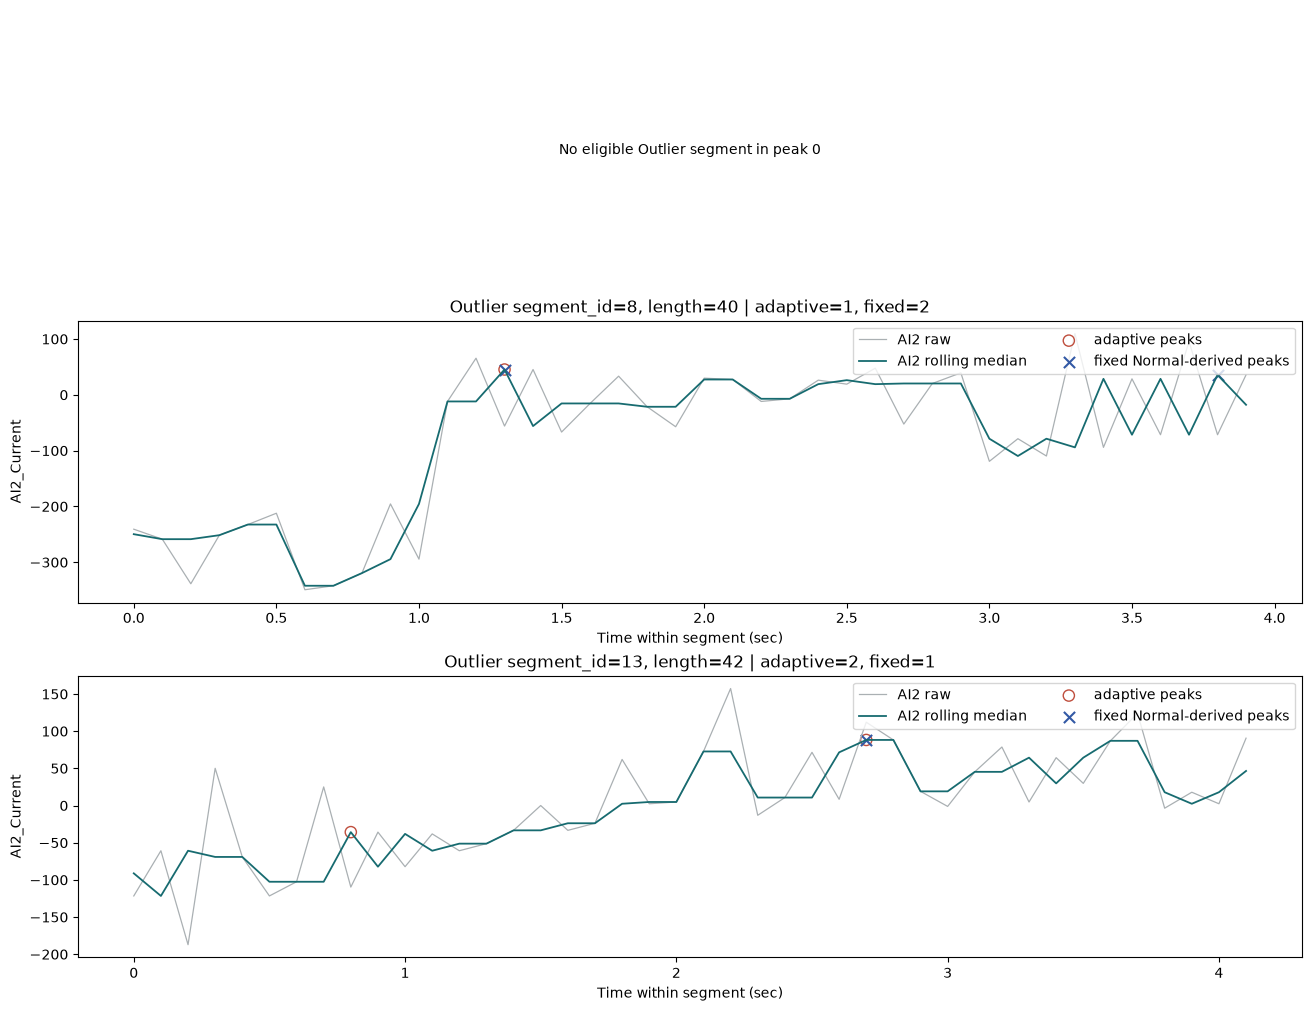

Peak-count increases under a fixed threshold are not treated as evidence of a better cycle detector; inspect alignment to visible waveform structure.


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), squeeze=False, constrained_layout=True)
for row_plot, (category, _) in enumerate(peak_categories):
    ax = axes[row_plot, 0]
    candidates = outlier_eligible.loc[outlier_eligible["peak_group"] == category]
    if candidates.empty:
        ax.text(0.5, 0.5, f"No eligible Outlier segment in {category}", ha="center", va="center")
        ax.set_axis_off()
        continue
    chosen_id = int(candidates.sort_values("segment_id").iloc[len(candidates) // 2]["segment_id"])
    group = outlier.loc[outlier["segment_id"] == chosen_id]
    raw = group[CYCLE_ANCHOR].to_numpy(dtype=float)
    smooth = pd.Series(raw).rolling(3, center=True, min_periods=1).median().to_numpy()
    adaptive = method_peak_locations[("Outlier", chosen_id, "Current adaptive")]
    fixed = method_peak_locations[("Outlier", chosen_id, "Fixed Normal-derived")]
    time = np.arange(len(group)) / SAMPLE_RATE_HZ
    ax.plot(time, raw, color="#aab0b3", linewidth=0.9, label="AI2 raw")
    ax.plot(time, smooth, color="#176b70", linewidth=1.3, label="AI2 rolling median")
    ax.scatter(time[adaptive], smooth[adaptive], marker="o", facecolors="none", edgecolors="#bf4e3d", s=65, label="adaptive peaks")
    ax.scatter(time[fixed], smooth[fixed], marker="x", color="#3359a5", s=65, label="fixed Normal-derived peaks")
    ax.set_title(f"Outlier segment_id={chosen_id}, length={len(group)} | adaptive={len(adaptive)}, fixed={len(fixed)}")
    ax.set_xlabel("Time within segment (sec)")
    ax.set_ylabel("AI2_Current")
    ax.legend(loc="upper right", ncol=2)
plt.show()
print("Peak-count increases under a fixed threshold are not treated as evidence of a better cycle detector; inspect alignment to visible waveform structure.")